Imports

In [7]:
import pandas as pd
import numpy as np
import pickle
import nltk
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('stopwords')
nltk.download('punkt')
from nltk.corpus import stopwords

print("All imports done ✅")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


All imports done ✅


In [6]:
import sys
!{sys.executable} -m pip install nltk

  Using cached nltk-3.9.4-py3-none-any.whl.metadata (3.2 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
Using cached nltk-3.9.4-py3-none-any.whl (1.6 MB)
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)

   ---------------------------------------- 0/3 [tqdm]
   ---------------------------------------- 0/3 [tqdm]
   ---------------------------------------- 0/3 [tqdm]
   ------------- -------------------------- 1/3 [regex]
   ------------- -------------------------- 1/3 [regex]
   ------------- -------------------------- 1/3 [regex]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Data Load + Combine

In [8]:
fake = pd.read_csv(r'E:\AI projects\fake-news-detector\data\Fake.csv')
true = pd.read_csv(r'E:\AI projects\fake-news-detector\data\True.csv')

fake['label'] = 0
true['label'] = 1

df = pd.concat([fake, true], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Title + Text combine karo
df['content'] = df['title'] + " " + df['text']
df = df[['content', 'label']].dropna()

print("Dataset shape:", df.shape)

Dataset shape: (44898, 2)


Text Cleaning Function

In [9]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)  # URLs hataao
    text = re.sub(r'<.*?>', '', text)                   # HTML tags
    text = re.sub(r'\d+', '', text)                     # Numbers
    text = text.translate(
        str.maketrans('', '', string.punctuation))       # Punctuation
    tokens = text.split()
    tokens = [w for w in tokens
              if w not in stop_words and len(w) > 2]    # Stopwords
    return " ".join(tokens)

print("Cleaning text... (2-3 min lagenge)")
df['clean_content'] = df['content'].apply(clean_text)
print("Text cleaning done ✅")

Cleaning text... (2-3 min lagenge)
Text cleaning done ✅


 Train/Test Split + TF-IDF

In [10]:
X = df['clean_content']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print("Train size:", X_train_tfidf.shape)
print("Test size :", X_test_tfidf.shape)
print("TF-IDF done ✅")

Train size: (35918, 10000)
Test size : (8980, 10000)
TF-IDF done ✅


Models Train

In [11]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest":       RandomForestClassifier(
                               n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)
    acc   = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"{name}: Accuracy = {acc*100:.2f}%\n")

Training Logistic Regression...
Logistic Regression: Accuracy = 99.04%

Training Random Forest...
Random Forest: Accuracy = 99.78%



Confusion Matrix

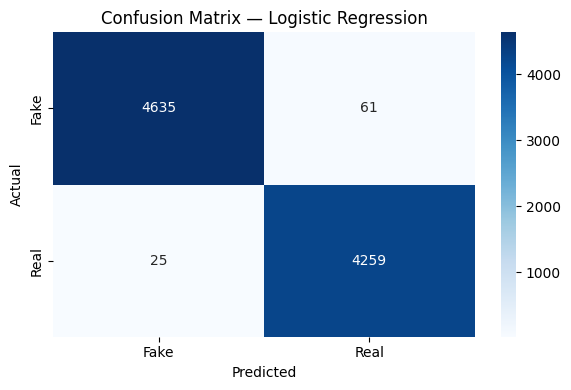


Classification Report:
              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      4696
        Real       0.99      0.99      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



In [12]:
best_model = models["Logistic Regression"]
preds      = best_model.predict(X_test_tfidf)

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d',
            cmap='Blues',
            xticklabels=['Fake', 'Real'],
            yticklabels=['Fake', 'Real'])
plt.title('Confusion Matrix — Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, preds,
      target_names=['Fake', 'Real']))

Model + Vectorizer 

In [14]:
# Model save
with open('../model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# TF-IDF save (zaruri hai!)
with open('../tfidf.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("Model saved ")
print("TF-IDF vectorizer saved ")

Model saved 
TF-IDF vectorizer saved 
